In [29]:
import pandas as pd

df = pd.read_csv('customer_churn_dataset.csv')

print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
None


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [30]:
def explore_data(data):
    # Check the number of rows and columns
    # Перевіряємо кількість рядків та стовпців
    print(f"Shape: {data.shape}")

    # Check data types for each column
    # Перевіряємо типи даних кожного стовпця
    print("\nData types:")
    print(data.dtypes)

    # Check for missing values in each column
    # Перевіряємо пропущені значення по кожному стовпцю
    print(f"\nMissing values per column:")
    print(data.isnull().sum())

    # Check for duplicate rows
    # Перевіряємо наявність дублікатів
    print(f"\nDuplicate rows: {data.duplicated().sum()}")

explore_data(df)

Shape: (440833, 12)

Data types:
CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

Missing values per column:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Duplicate rows: 0


In [31]:
def clean_data(data):
    # Drop the single row with missing values
    # Видаляємо єдиний рядок з пропущеними значеннями
    data = data.dropna()

    # Convert float columns to int where it makes sense
    # Конвертуємо float-стовпці в int там, де це логічно
    cols_to_int = ['CustomerID', 'Age', 'Tenure', 'Usage Frequency',
                   'Support Calls', 'Payment Delay', 'Total Spend',
                   'Last Interaction', 'Churn']
    data[cols_to_int] = data[cols_to_int].astype(int)

    print(f"Data cleaned successfully! Shape: {data.shape}")
    print(f"Missing values remaining: {data.isnull().sum().sum()}")

    return data

df_cleaned = clean_data(df)

Data cleaned successfully! Shape: (440832, 12)
Missing values remaining: 0


/tmp/ipykernel_5436/707036202.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[cols_to_int] = data[cols_to_int].astype(int)


In [32]:
explore_data(df_cleaned)

Shape: (440832, 12)

Data types:
CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

Missing values per column:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

Duplicate rows: 0


In [33]:
def explore_churn_overview(data):
    # Calculate overall churn rate
    # Розраховуємо загальний показник відтоку
    churn_rate = data['Churn'].mean() * 100
    churn_counts = data['Churn'].value_counts()

    print(f"Total customers: {len(data):,}")
    print(f"\nChurn distribution:")
    print(f"  Stayed  (0): {churn_counts[0]:,} ({100 - churn_rate:.1f}%)")
    print(f"  Churned (1): {churn_counts[1]:,} ({churn_rate:.1f}%)")

explore_churn_overview(df_cleaned)

Total customers: 440,832

Churn distribution:
  Stayed  (0): 190,833 (43.3%)
  Churned (1): 249,999 (56.7%)


In [34]:
def explore_numeric_stats(data):
    # Calculate descriptive statistics for numeric columns
    # Розраховуємо описову статистику для числових стовпців
    numeric_cols = ['Age', 'Tenure', 'Usage Frequency',
                    'Support Calls', 'Payment Delay',
                    'Total Spend', 'Last Interaction']

    print("Descriptive statistics:")
    print(data[numeric_cols].describe().round(2))

explore_numeric_stats(df_cleaned)

Descriptive statistics:
             Age     Tenure  Usage Frequency  Support Calls  Payment Delay  \
count  440832.00  440832.00        440832.00      440832.00      440832.00   
mean       39.37      31.26            15.81           3.60          12.97   
std        12.44      17.26             8.59           3.07           8.26   
min        18.00       1.00             1.00           0.00           0.00   
25%        29.00      16.00             9.00           1.00           6.00   
50%        39.00      32.00            16.00           3.00          12.00   
75%        48.00      46.00            23.00           6.00          19.00   
max        65.00      60.00            30.00          10.00          30.00   

       Total Spend  Last Interaction  
count    440832.00         440832.00  
mean        631.34             14.48  
std         240.72              8.60  
min         100.00              1.00  
25%         480.00              7.00  
50%         661.00             14.00  


In [35]:
def explore_categorical_cols(data):
    # Check value counts for each categorical column
    # Перевіряємо розподіл категоріальних стовпців
    cat_cols = ['Gender', 'Subscription Type', 'Contract Length']

    for col in cat_cols:
        print(f"\n{col}:")
        counts = data[col].value_counts()
        pct = data[col].value_counts(normalize=True) * 100
        for val in counts.index:
            print(f"  {val}: {counts[val]:,} ({pct[val]:.1f}%)")

explore_categorical_cols(df_cleaned)


Gender:
  Male: 250,252 (56.8%)
  Female: 190,580 (43.2%)

Subscription Type:
  Standard: 149,128 (33.8%)
  Premium: 148,678 (33.7%)
  Basic: 143,026 (32.4%)

Contract Length:
  Annual: 177,198 (40.2%)
  Quarterly: 176,530 (40.0%)
  Monthly: 87,104 (19.8%)


In [36]:
def explore_churn_by_category(data):
    # Calculate churn rate for each categorical column
    # Розраховуємо відсоток відтоку по категоріальних стовпцях
    cat_cols = ['Gender', 'Subscription Type', 'Contract Length']

    for col in cat_cols:
        print(f"\nChurn rate by {col}:")
        churn_by_col = data.groupby(col)['Churn'].mean() * 100
        churn_by_col = churn_by_col.round(1).sort_values(ascending=False)
        for val, rate in churn_by_col.items():
            print(f"  {val}: {rate}%")

explore_churn_by_category(df_cleaned)


Churn rate by Gender:
  Female: 66.7%
  Male: 49.1%

Churn rate by Subscription Type:
  Basic: 58.2%
  Standard: 56.1%
  Premium: 55.9%

Churn rate by Contract Length:
  Monthly: 100.0%
  Annual: 46.1%
  Quarterly: 46.0%


In [37]:
def explore_churn_by_numeric(data):
    # Compare average values of numeric columns between churned and retained customers
    # Порівнюємо середні значення числових показників між клієнтами що пішли і залишились
    numeric_cols = ['Age', 'Tenure', 'Usage Frequency',
                    'Support Calls', 'Payment Delay',
                    'Total Spend', 'Last Interaction']

    print("Average values — Churned (1) vs Stayed (0):")
    print(data.groupby('Churn')[numeric_cols].mean().round(2))

explore_churn_by_numeric(df_cleaned)

Average values — Churned (1) vs Stayed (0):
         Age  Tenure  Usage Frequency  Support Calls  Payment Delay  \
Churn                                                                 
0      36.26   32.28            16.26           1.59          10.02   
1      41.75   30.47            15.46           5.14          15.22   

       Total Spend  Last Interaction  
Churn                                 
0           749.47             13.01  
1           541.18             15.60  


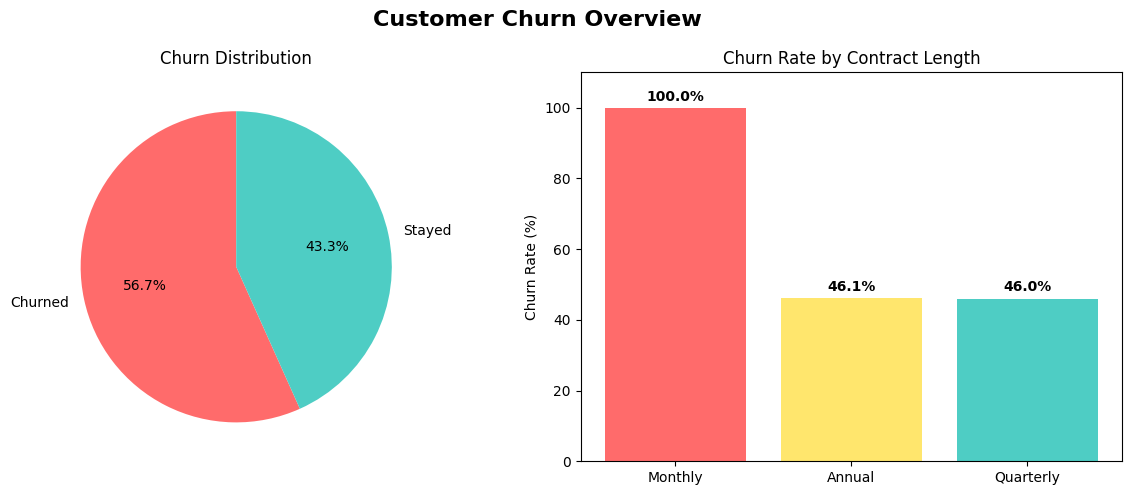

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_churn_overview(data):
    # Set up the figure with two subplots side by side
    # Налаштовуємо фігуру з двома графіками поруч
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Customer Churn Overview', fontsize=16, fontweight='bold')

    # Plot 1: Churn distribution as a pie chart
    # Графік 1: Розподіл відтоку у вигляді кругової діаграми
    churn_counts = data['Churn'].value_counts()
    axes[0].pie(churn_counts, labels=['Churned', 'Stayed'],
                autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'],
                startangle=90)
    axes[0].set_title('Churn Distribution')

    # Plot 2: Churn rate by Contract Length
    # Графік 2: Відсоток відтоку за типом контракту
    churn_by_contract = data.groupby('Contract Length')['Churn'].mean() * 100
    churn_by_contract = churn_by_contract.sort_values(ascending=False)
    axes[1].bar(churn_by_contract.index, churn_by_contract.values,
                color=['#FF6B6B', '#FFE66D', '#4ECDC4'])
    axes[1].set_title('Churn Rate by Contract Length')
    axes[1].set_ylabel('Churn Rate (%)')
    axes[1].set_ylim(0, 110)
    for i, val in enumerate(churn_by_contract.values):
        axes[1].text(i, val + 2, f'{val:.1f}%', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_churn_overview(df_cleaned)

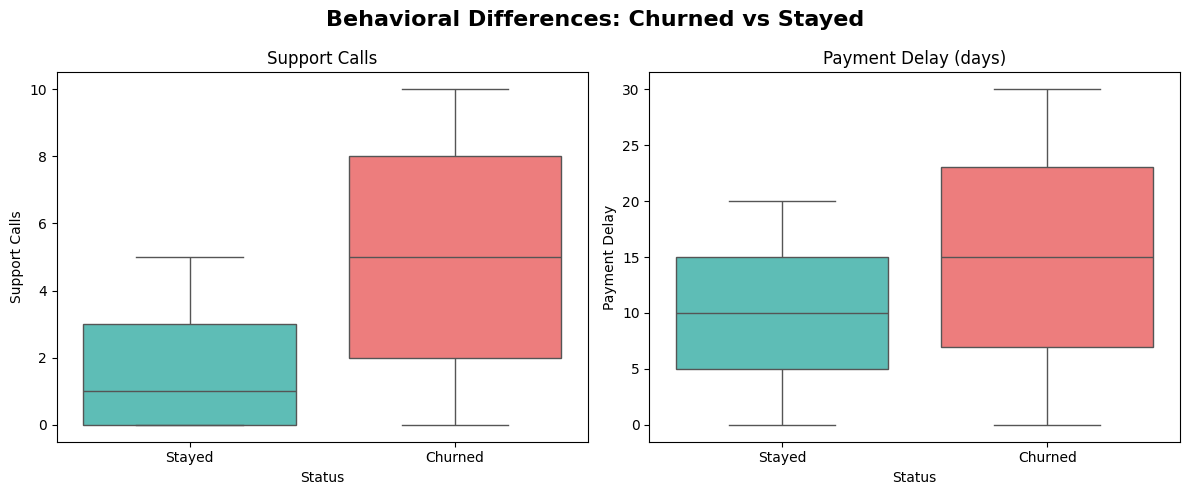

In [39]:
def plot_churn_by_behavior(data):
    # Compare key behavioral metrics between churned and retained customers
    # Порівнюємо ключові поведінкові показники між клієнтами що пішли і залишились
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Behavioral Differences: Churned vs Stayed', fontsize=16, fontweight='bold')

    # Create a labeled copy to avoid deprecation warning
    # Створюємо копію з підписами щоб уникнути попередження
    plot_data = data.copy()
    plot_data['Status'] = plot_data['Churn'].map({0: 'Stayed', 1: 'Churned'})

    # Plot 1: Support Calls distribution
    # Графік 1: Розподіл кількості дзвінків у підтримку
    sns.boxplot(data=plot_data, x='Status', y='Support Calls',
                hue='Status', palette={'Stayed': '#4ECDC4', 'Churned': '#FF6B6B'},
                order=['Stayed', 'Churned'], legend=False, ax=axes[0])
    axes[0].set_title('Support Calls')

    # Plot 2: Payment Delay distribution
    # Графік 2: Розподіл затримок платежів
    sns.boxplot(data=plot_data, x='Status', y='Payment Delay',
                hue='Status', palette={'Stayed': '#4ECDC4', 'Churned': '#FF6B6B'},
                order=['Stayed', 'Churned'], legend=False, ax=axes[1])
    axes[1].set_title('Payment Delay (days)')

    plt.tight_layout()
    plt.show()

plot_churn_by_behavior(df_cleaned)

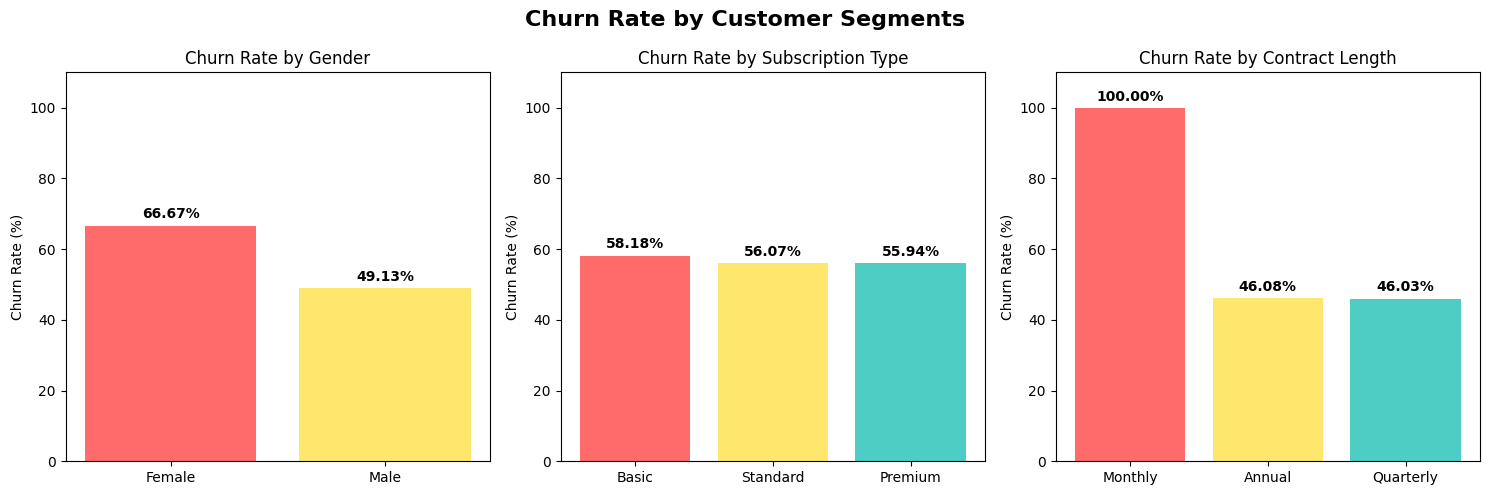

In [40]:
def plot_churn_by_category(data):
    # Compare churn rate across all categorical columns
    # Порівнюємо відсоток відтоку по всіх категоріальних стовпцях
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Churn Rate by Customer Segments', fontsize=16, fontweight='bold')

    cat_cols = ['Gender', 'Subscription Type', 'Contract Length']

    for i, col in enumerate(cat_cols):
        churn_rate = data.groupby(col)['Churn'].mean() * 100
        churn_rate = churn_rate.sort_values(ascending=False)
        axes[i].bar(churn_rate.index, churn_rate.values, color=['#FF6B6B', '#FFE66D', '#4ECDC4'])
        axes[i].set_title(f'Churn Rate by {col}')
        axes[i].set_ylabel('Churn Rate (%)')
        axes[i].set_ylim(0, 110)
        for j, val in enumerate(churn_rate.values):
            axes[i].text(j, val + 2, f'{val:.2f}%', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_churn_by_category(df_cleaned)

In [41]:
def print_key_findings(data):
    # Summarize the main analytical findings from the EDA
    # Підсумовуємо головні аналітичні висновки по результатах EDA

    print("=" * 55)
    print("KEY FINDINGS — CUSTOMER CHURN ANALYSIS")
    print("=" * 55)

    churn_rate = data['Churn'].mean() * 100
    print(f"\n1. Overall churn rate: {churn_rate:.1f}% (critically high)")

    contract_churn = data.groupby('Contract Length')['Churn'].mean() * 100
    print(f"\n2. Contract Length is the strongest churn driver:")
    for k, v in contract_churn.sort_values(ascending=False).items():
        print(f"   {k}: {v:.1f}%")

    gender_churn = data.groupby('Gender')['Churn'].mean() * 100
    print(f"\n3. Gender gap in churn:")
    for k, v in gender_churn.sort_values(ascending=False).items():
        print(f"   {k}: {v:.1f}%")

    means = data.groupby('Churn')[['Support Calls', 'Payment Delay', 'Total Spend']].mean()
    print(f"\n4. Churned vs Stayed — behavioral signals:")
    print(f"   Support Calls:  {means.loc[1,'Support Calls']:.1f} vs {means.loc[0,'Support Calls']:.1f}")
    print(f"   Payment Delay:  {means.loc[1,'Payment Delay']:.1f} vs {means.loc[0,'Payment Delay']:.1f} days")
    print(f"   Total Spend:    ${means.loc[1,'Total Spend']:.0f} vs ${means.loc[0,'Total Spend']:.0f}")

    print(f"\n5. Subscription Type: no significant impact (55–58%)")
    print("=" * 55)

print_key_findings(df_cleaned)

KEY FINDINGS — CUSTOMER CHURN ANALYSIS

1. Overall churn rate: 56.7% (critically high)

2. Contract Length is the strongest churn driver:
   Monthly: 100.0%
   Annual: 46.1%
   Quarterly: 46.0%

3. Gender gap in churn:
   Female: 66.7%
   Male: 49.1%

4. Churned vs Stayed — behavioral signals:
   Support Calls:  5.1 vs 1.6
   Payment Delay:  15.2 vs 10.0 days
   Total Spend:    $541 vs $749

5. Subscription Type: no significant impact (55–58%)


In [42]:
def export_for_tableau(data):
    # Save cleaned dataset for Tableau dashboard
    # Зберігаємо очищений датасет для дашборду в Tableau
    data.to_csv('customer_churn_cleaned.csv', index=False)

    print(f"File saved successfully: customer_churn_cleaned.csv")
    print(f"Rows: {len(data):,}")
    print(f"Columns: {list(data.columns)}")

export_for_tableau(df_cleaned)

File saved successfully: customer_churn_cleaned.csv
Rows: 440,832
Columns: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']
